In [41]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

In [42]:
import nltk
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer,PorterStemmer
from nltk.corpus import wordnet

In [43]:
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [47]:
# https://www.kaggle.com/shivamkushwaha/bbc-full-text-document-classification

!wget -nc https://lazyprogammer.me/course_files/nlp/bbc_text_cls.csv

--2024-04-04 07:34:43--  https://lazyprogammer.me/course_files/nlp/bbc_text_cls.csv
Resolving lazyprogammer.me (lazyprogammer.me)... failed: Name or service not known.
wget: unable to resolve host address ‘lazyprogammer.me’


In [49]:
df = pd.read_csv('/content/bbc-text.csv')

In [50]:
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [51]:
inputs = df['text']
labels = df['category']

<Axes: >

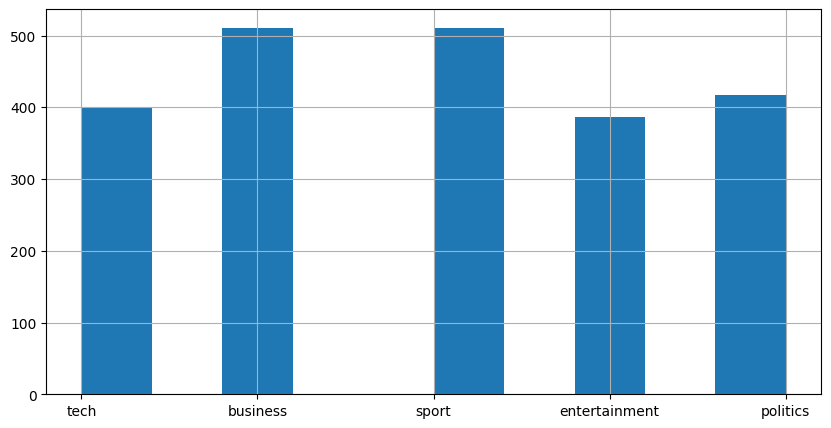

In [52]:
labels.hist(figsize = (10,5))

In [53]:
 inputs_train, inputs_test, Ytrain, Ytest = train_test_split(
     inputs, labels , random_state = 42
 )

In [55]:
vectorizer = CountVectorizer()

In [56]:
Xtrain = vectorizer.fit_transform(inputs_train)
Xtest = vectorizer.transform(inputs_test)

In [57]:
Xtrain

<1668x25852 sparse matrix of type '<class 'numpy.int64'>'
	with 336899 stored elements in Compressed Sparse Row format>

In [58]:
(Xtrain != 0).sum()

336899

In [59]:
(Xtrain != 0).sum() / np.prod(Xtrain.shape)

0.007812850756065425

In [60]:
model = MultinomialNB()
model.fit(Xtrain, Ytrain)
print("train score:", model.score(Xtrain, Ytrain))
print("test score:", model.score(Xtest,Ytest))

train score: 0.9934052757793765
test score: 0.9730700179533214


In [61]:
# with stopwords

vectorizer = CountVectorizer(stop_words = 'english')
Xtrain = vectorizer.fit_transform(inputs_train)
Xtest = vectorizer.transform(inputs_test)

model = MultinomialNB()
model.fit(Xtrain, Ytrain)
print("train score:", model.score(Xtrain, Ytrain))
print("test score:", model.score(Xtest,Ytest))


train score: 0.9958033573141487
test score: 0.9712746858168761


In [65]:


def get_wordnet_pos(treebank_tag):
  if treebank_tag.startswith('J'):
    return wordnet.ADJ
  elif treebank_tag.startswith('V'):
    return wordnet.VERB
  elif treebank_tag.startswith('N'):
    return wordnet.NOUN
  elif treebank_tag.startswith('R'):
    return wordnet.ADV

  else:
    return wordnet.NOUN

In [67]:
class LemmaTokenizer:
  def  __init__(self):
    self.wnl = WordNetLemmatizer()
  def __call__(self, doc):
    tokens = word_tokenize(doc)
    words_and_tags = nltk.pos_tag(tokens)
    return [self.wnl.lemmatize(word, pos = get_wordnet_pos(tag)) \
            for word, tag in words_and_tags]


In [72]:
# with lemmatization

vectorizer = CountVectorizer(tokenizer = LemmaTokenizer())
Xtrain = vectorizer.fit_transform(inputs_train)
Xtest = vectorizer.transform(inputs_test)

model = MultinomialNB()
model.fit(Xtrain, Ytrain)
print("train score:", model.score(Xtrain, Ytrain))
print("test score:", model.score(Xtest,Ytest))


train score: 0.9940047961630696
test score: 0.9712746858168761


In [73]:
class StemTokenizer:
  def __init__(self):
    self.porter = PorterStemmer()
  def __call__(self, doc):
    tokens = word_tokenize(doc)
    return [self.porter.stem(t) for t in tokens]

In [74]:
# with stemming

vectorizer= CountVectorizer(tokenizer=StemTokenizer())
Xtrain = vectorizer.fit_transform(inputs_train)
Xtest = vectorizer.transform(inputs_test)

model = MultinomialNB()
model.fit(Xtrain, Ytrain)
print("train score:", model.score(Xtrain, Ytrain))
print("test score:", model.score(Xtest,Ytest))


/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


train score: 0.9928057553956835
test score: 0.9730700179533214


In [75]:
def simple_tokenizer(s):
  return s.split()

In [76]:
vectorizer = CountVectorizer(tokenizer = simple_tokenizer)
Xtrain = vectorizer.fit_transform(inputs_train)
Xtest = vectorizer.transform(inputs_test)

model = MultinomialNB()
model.fit(Xtrain, Ytrain)
print("train score:", model.score(Xtrain, Ytrain))
print("test score:", model.score(Xtest,Ytest))


/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


train score: 0.9958033573141487
test score: 0.9712746858168761
